# Marching Qubes Vertex Classification with EHands and QCrank
## Brandon Watanabe


In [1]:
# imports, part 1
import numpy as np
import matplotlib.pyplot as plt
import math
from math import asin, sqrt, pi
import random
import sys
from dotenv import load_dotenv
import os
from pathlib import Path
from collections import defaultdict

import qiskit
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_distribution, array_to_latex
from qiskit.circuit.library import HGate, XGate, YGate, ZGate, CXGate
print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.3.0


In [2]:
# Adapted from Chris Pestano's QSobel
load_dotenv()
data_encoder_circuits_path = os.getenv('DATA_ENCODER_CIRCUITS_PATH')

if data_encoder_circuits_path is None:
    raise EnvironmentError("DATA_ENCODER_CIRCUITS_PATH environment variable is not set. Please set it to the path of data-encoder-circuits.")

print(f"Using DATA_ENCODER_CIRCUITS_PATH from environment variable: {data_encoder_circuits_path}")
circuits_path = data_encoder_circuits_path

# Add to sys.path if not already present
if circuits_path not in sys.path:
    sys.path.insert(0, circuits_path)

print(f"Added to sys.path: {circuits_path}")
print(f"Current working directory: {os.getcwd()}")

from datacircuits import qcrank, frqi
from datacircuits import ParametricQCrankV2
from datacircuits.ParametricQCrankV2 import ParametricQCrankV2 as qcrank_reco_from_yields

Using DATA_ENCODER_CIRCUITS_PATH from environment variable: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Added to sys.path: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Current working directory: c:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis


In [2]:
# Adapted from Chris Pestano's QSobel
default_data_encoder_circuits_path = str(Path(r'C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits').resolve())
data_encoder_circuits_path = os.getenv('DATA_ENCODER_CIRCUITS_PATH')

# Use environment variable if set, otherwise use default path
if data_encoder_circuits_path:
    print(f"Using DATA_ENCODER_CIRCUITS_PATH from environment variable: {data_encoder_circuits_path}")
    circuits_path = data_encoder_circuits_path
else:
    print(f"Using default path: {default_data_encoder_circuits_path}")
    circuits_path = default_data_encoder_circuits_path

# Add to sys.path if not already present
if circuits_path not in sys.path:
    sys.path.insert(0, circuits_path)

print(f"Added to sys.path: {circuits_path}")
print(f"Current working directory: {os.getcwd()}")

from datacircuits import qcrank, frqi
from datacircuits import ParametricQCrankV2
from datacircuits.ParametricQCrankV2 import ParametricQCrankV2 as qcrank_reco_from_yields

Using default path: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Added to sys.path: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Current working directory: c:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis


In [131]:
from qiskit_aer import AerSimulator

sim = AerSimulator()

print(sim)
print(f"\nConfiguration: {sim.configuration()}")

if hasattr(sim, 'available_methods'):
    print(f"Available methods: {sim.available_methods()}")
else:
    print(sim.configuration())

if hasattr(sim, 'available_devices'):
    print(f"Available devices: {sim.available_devices()}")
else:
    print(sim.configuration())   

AerSimulator('aer_simulator')

Configuration: <qiskit_aer.backends.backendconfiguration.AerBackendConfiguration object at 0x000002367C16C2F0>
Available methods: ('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')
Available devices: ('CPU',)


In [132]:
# helper function needed to use plot_bloch_vector() method: converts statevector to 3 values
def statevector_to_bloch_vector(state):
    bloch_x = 2 * np.real(state[0] * np.conj(state[1]))
    bloch_y = 2 * np.imag(state[1] * np.conj(state[0]))
    bloch_z = np.abs(state[0])**2 - np.abs(state[1])**2
    return [bloch_x, bloch_y, bloch_z]

# helper function to plot two bloch spheres side by side
# inputs are two statevectors and two title strings
def plot_2bloch_spheres(state1, title1, state2, title2):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': '3d'})
    
    plot_bloch_vector(statevector_to_bloch_vector(state1), ax=axs[0])
    axs[0].set_title(title1, pad=20)

    plot_bloch_vector(statevector_to_bloch_vector(state2), ax=axs[1])
    axs[1].set_title(title2, pad=20)

    plt.show()

In [133]:
def run_sim_job(qc, n_shots = 2**8):
    transpiled_circuit = transpile(qc, sim)
    
    print("Circuit before transpilation")
    display(qc.draw('mpl'))
    print("Circuit after transpilation")
    display(transpiled_circuit.draw('mpl', style="iqp"))
    
    job = sim.run(transpiled_circuit, shots=n_shots)
    result = job.result()
    
    # Get counts and output distribution
    counts = result.get_counts(transpiled_circuit)

    print("Counts:")
    print(counts)
    
    display(plot_distribution(counts))

    return counts

In [134]:
def display_statevector(qc):
    # Get Statevector
    state = Statevector.from_instruction(qc)

    # Display Statevector
    print("\nStatevector:")
    display(state.draw("latex"))

    matrix_form = np.array(state).reshape(-1, 1)
    print("\nStatevector as a matrix:")
    display(array_to_latex(matrix_form))
    
    # Display the Unitary Matrix
    print("Unitary matrix:")
    display(Operator(qc).draw("latex"))

    # Display Bloch Sphere
    display(plot_bloch_multivector(state))

    return state

In [135]:
def compute_qubit_counts(data):
    # TODO: Handle non-power-of-two datasets
    data = np.array(data)
    n_data = data.shape[0]

    # number of data qubits
    if data.ndim == 1:
        data_qubits = 1
    else:
        data_qubits = data.shape[1]

    # number of address qubits
    address_qubits = math.ceil(math.log2(n_data))

    return address_qubits, data_qubits

In [ ]:
def encode_with_qcrank(data):
    nq_addr, nq_data = compute_qubit_counts(data)

    print("Number of address qubits needed:", nq_addr)
    print("Number of data qubits needed:", nq_data)

    # reshape data to have shape (n_data, nq_data, 1) for compatibility with the data encoding circuit
    data = data.reshape(n_data, nq_data, 1)
    print("Input data values:")
    print(data) 

    # Adapted from Chris Pestano's QSobel
    # This function is from an outside directory provided by the AQuA-DATA team at LBNL (see data-encoder-circuits directory)
    param_qcrankObj = ParametricQCrankV2.ParametricQCrankV2( nq_addr, nq_data, useCZ=False, measure=False, barrier=True )
    # Important NOTE: QCrankV2 has address qubits on the LSQBs, V1 had an option to reverse bits during initialization, but that is not present in V2

    param_qcrankObj.bind_data(data)
    # generate the instantiated circuits
    # rotation gates values are mapped to their respective gates 
    data_circs = param_qcrankObj.instantiate_circuits()
    print(f"Generated {len(data_circs)} data encoding circuits.")
    addr_qubits = list(range(nq_addr))

    return {
    'data_circs': data_circs,
    'param_qcrankObj': param_qcrankObj,
    'nq_addr': nq_addr,
    'nq_data': nq_data,
    'addr_qubits': addr_qubits
    }

Number of address qubits needed: 3
Number of data qubits needed: 1
Input data values:
[[[0.        ]]

 [[0.14285714]]

 [[0.28571429]]

 [[0.42857143]]

 [[0.57142857]]

 [[0.71428571]]

 [[0.85714286]]

 [[1.        ]]]
Generated 1 data encoding circuits.
Generated data encoding circuit:

Statevector:


<IPython.core.display.Latex object>


Statevector as a matrix:


<IPython.core.display.Latex object>

Unitary matrix:


<IPython.core.display.Latex object>

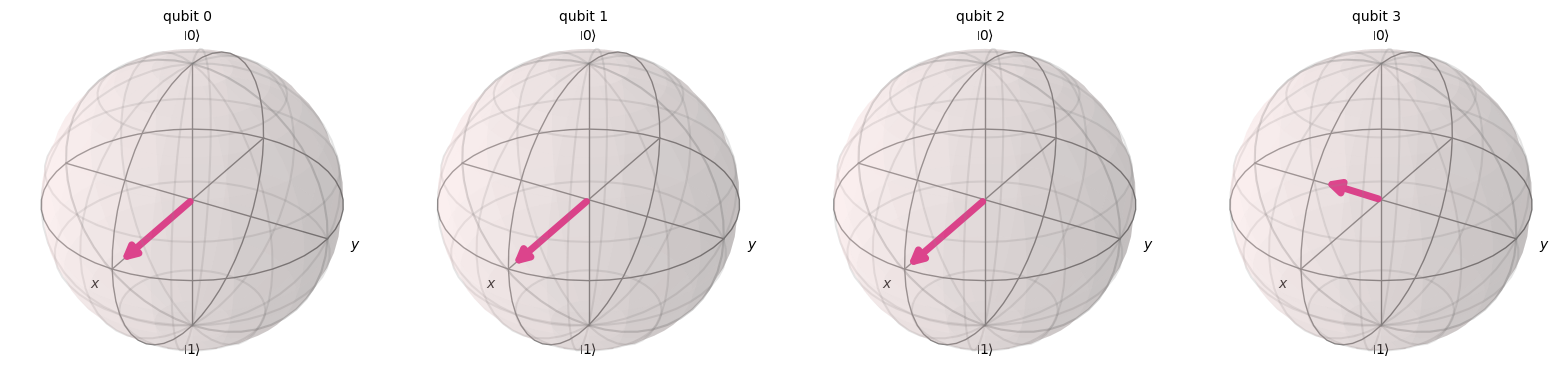

In [136]:
# Marching Cubes Vertex Classification
iso_value = 0.5

# Small sample data for testing
n_cubes = 1
n_data = n_cubes * 2**3
data = np.linspace(0, 1, n_data)

encoding_args = encode_with_qcrank(data)

print(encoding_args)

state = display_statevector(qc)


Circuit before transpilation


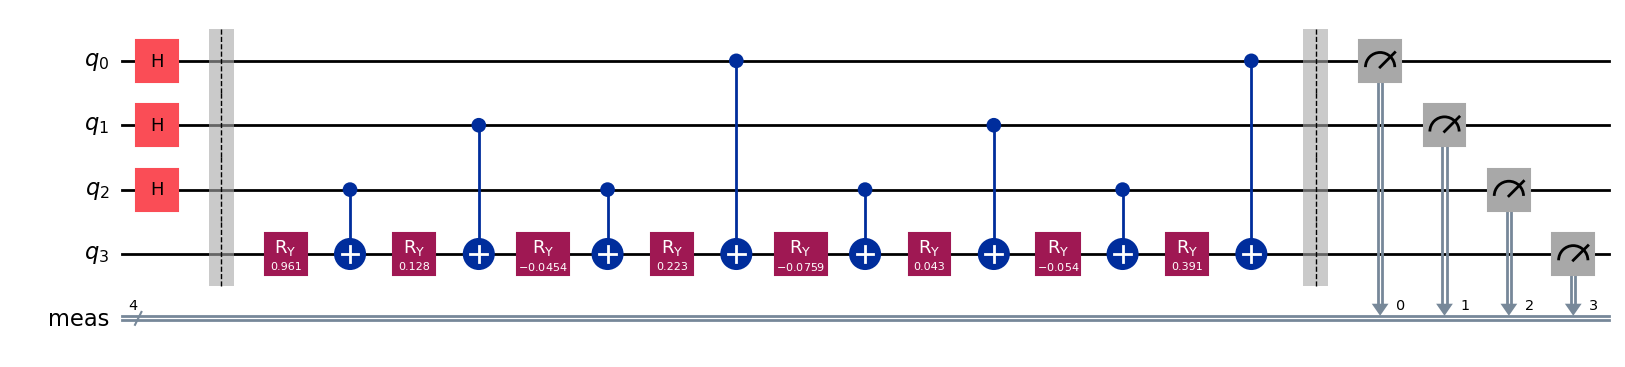

Circuit after transpilation


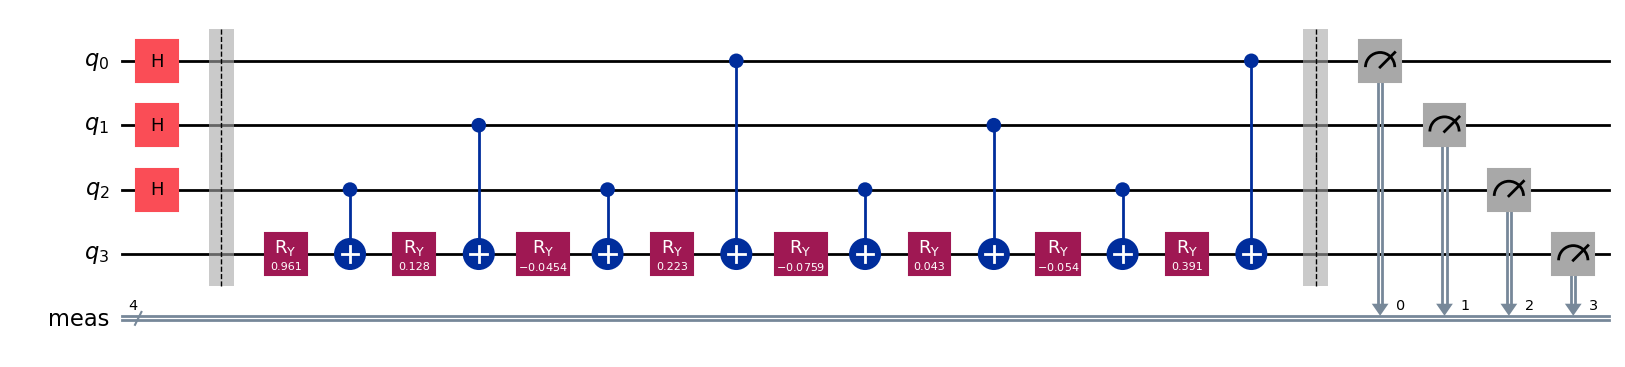

Counts:
{'0110': 106, '0011': 121, '0001': 110, '0000': 54, '0101': 113, '0111': 124, '0010': 78, '0100': 83, '1001': 27, '1100': 55, '1010': 34, '1000': 62, '1110': 37, '1101': 12, '1011': 8}


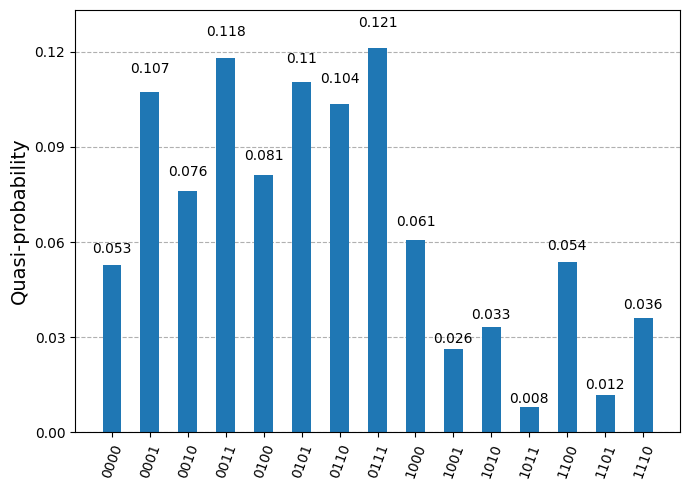

In [137]:
qc.measure_all()

counts = run_sim_job(qc, n_shots=2**10)